### Importación de datos



In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [50]:
tienda1.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

#1. Análisis de facturación



In [51]:
ingreso_total_tienda1 = tienda1['Precio'].sum()
ingreso_total_tienda2 = tienda2['Precio'].sum()
ingreso_total_tienda3 = tienda3['Precio'].sum()
ingreso_total_tienda4 = tienda4['Precio'].sum()
ingresos_totales = {
    'Tiendas': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    'Ingreso Total': [ingreso_total_tienda1, ingreso_total_tienda2, ingreso_total_tienda3, ingreso_total_tienda4]
}
itdf = pd.DataFrame(ingresos_totales).sort_values(by='Ingreso Total', ascending=False)
itdf

,Tiendas,Ingreso Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


# 2. Ventas por categoría

In [52]:
ventas_categoria1 = tienda1.groupby('Categoría del Producto').size().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
ventas_categoria2 = tienda2.groupby('Categoría del Producto').size().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
ventas_categoria3 = tienda3.groupby('Categoría del Producto').size().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
ventas_categoria4 = tienda4.groupby('Categoría del Producto').size().reset_index(name='Ventas').sort_values(by='Ventas', ascending=False)
display(ventas_categoria1, ventas_categoria2, ventas_categoria3, ventas_categoria4)

,Categoría del Producto,Ventas
7,Muebles,465
3,Electrónicos,448
5,Juguetes,324
2,Electrodomésticos,312
1,Deportes y diversión,284
4,Instrumentos musicales,182
6,Libros,173
0,Artículos para el hogar,171


,Categoría del Producto,Ventas
7,Muebles,442
3,Electrónicos,422
5,Juguetes,313
2,Electrodomésticos,305
1,Deportes y diversión,275
4,Instrumentos musicales,224
6,Libros,197
0,Artículos para el hogar,181


,Categoría del Producto,Ventas
7,Muebles,499
3,Electrónicos,451
5,Juguetes,315
2,Electrodomésticos,278
1,Deportes y diversión,277
6,Libros,185
0,Artículos para el hogar,177
4,Instrumentos musicales,177


,Categoría del Producto,Ventas
7,Muebles,480
3,Electrónicos,451
5,Juguetes,338
1,Deportes y diversión,277
2,Electrodomésticos,254
0,Artículos para el hogar,201
6,Libros,187
4,Instrumentos musicales,170


# 3. Calificación promedio de la tienda


In [53]:
media1 = round(tienda1['Calificación'].mean(), 2)
media2 = round(tienda2['Calificación'].mean(), 2)
media3 = round(tienda3['Calificación'].mean(), 2)
media4 = round(tienda4['Calificación'].mean(), 2)
calificacion_promedio = {
    'Tiendas': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    'Calificacion Promedio': [media1, media2, media3, media4]
}
c_promedio = pd.DataFrame(calificacion_promedio).sort_values(by='Calificacion Promedio', ascending=False)
c_promedio

,Tiendas,Calificacion Promedio
2,Tienda 3,4.05
1,Tienda 2,4.04
3,Tienda 4,4.00
0,Tienda 1,3.98


# 4. Productos más y menos vendidos

In [100]:
productos_mas_vendidos1 = tienda1.groupby('Producto').size().reset_index(name='Top productos').sort_values(by='Top productos', ascending=False)
productos_mas_vendidos2 = tienda2.groupby('Producto').size().reset_index(name='Top productos').sort_values(by='Top productos', ascending=False)
productos_mas_vendidos3 = tienda3.groupby('Producto').size().reset_index(name='Top productos').sort_values(by='Top productos', ascending=False)
productos_mas_vendidos4 = tienda4.groupby('Producto').size().reset_index(name='Top productos').sort_values(by='Top productos', ascending=False)
display(productos_mas_vendidos1.head(), productos_mas_vendidos2.head(), productos_mas_vendidos3.head(), productos_mas_vendidos4.head())

,Producto,Top productos
1,Armario,60
48,TV LED UHD 4K,60
33,Microondas,60
40,Secadora de ropa,58
32,Mesa de noche,56


,Producto,Top productos
24,Iniciando en programación,65
33,Microondas,62
7,Batería,61
38,Pandereta,58
21,Guitarra acústica,58


,Producto,Top productos
27,Kit de bancas,57
31,Mesa de comedor,56
11,Cama king,56
41,Set de ollas,55
32,Mesa de noche,55


,Producto,Top productos
10,Cama box,62
15,Cubertería,59
11,Cama king,56
18,Dashboards con Power BI,56
12,Carrito de control remoto,55


In [102]:
productos_menos_vendidos1 = tienda1.groupby('Producto').size().reset_index(name='Bottom productos').sort_values(by='Bottom productos', ascending=True)
productos_menos_vendidos2 = tienda2.groupby('Producto').size().reset_index(name='Bottom productos').sort_values(by='Bottom productos', ascending=True)
productos_menos_vendidos3 = tienda3.groupby('Producto').size().reset_index(name='Bottom productos').sort_values(by='Bottom productos', ascending=True)
productos_menos_vendidos4 = tienda4.groupby('Producto').size().reset_index(name='Bottom productos').sort_values(by='Bottom productos', ascending=True)
display(productos_menos_vendidos1.head(), productos_menos_vendidos2.head(), productos_menos_vendidos3.head(), productos_menos_vendidos4.head())

,Producto,Bottom productos
4,Auriculares con micrófono,33
13,Celular ABXY,33
37,Olla de presión,35
38,Pandereta,36
14,Ciencia de datos con Python,39


,Producto,Bottom productos
26,Juego de mesa,32
23,Impresora,34
31,Mesa de comedor,34
44,Sillón,35
3,Auriculares,37


,Producto,Bottom productos
9,Bloques de construcción,35
42,Set de vasos,36
34,Mochila,36
33,Microondas,36
50,Vaso térmico,38


,Producto,Bottom productos
22,Guitarra eléctrica,33
1,Armario,34
21,Guitarra acústica,37
14,Ciencia de datos con Python,38
28,Lavadora de ropa,38


# 5. Envío promedio por tienda

In [56]:
promedio_envio_tienda1 = tienda1['Costo de envío'].mean()
promedio_envio_tienda2 = tienda2['Costo de envío'].mean()
promedio_envio_tienda3 = tienda3['Costo de envío'].mean()
promedio_envio_tienda4 = tienda4['Costo de envío'].mean()
promedio_envio = {
    'Tiendas': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    'Promedio envio': [promedio_envio_tienda1,promedio_envio_tienda2,promedio_envio_tienda3,promedio_envio_tienda4]
}
promedio_envio = pd.DataFrame(promedio_envio).sort_values(by='Promedio envio', ascending=False)
promedio_envio

,Tiendas,Promedio envio
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


# Gráficos

##**Ingresos totales por tienda**

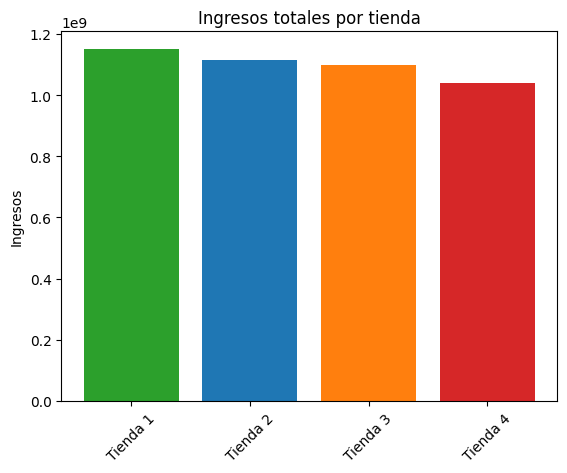

In [58]:
fig, ax1 = plt.subplots()

bar_colors = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']

ax1.bar(itdf['Tiendas'], itdf['Ingreso Total'], color=bar_colors)
ax1.set_ylabel('Ingresos')
ax1.set_title('Ingresos totales por tienda')
ax1.tick_params(axis='x', labelrotation=45)
plt.show()

## **Calificaciones de las tiendas**

Text(0.5, 1.0, 'Calificaciones de las tiendas')

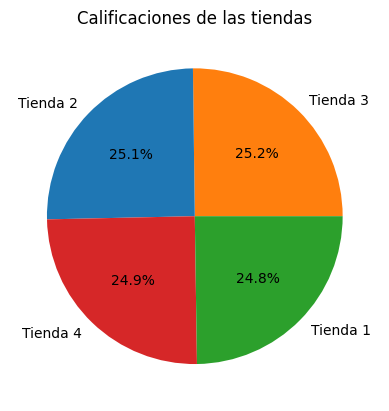

In [65]:
fig, ax2 = plt.subplots()
bar_colors2 = ['tab:orange', 'tab:blue', 'tab:red', 'tab:green']
ax2.pie(c_promedio['Calificacion Promedio'], colors=bar_colors2, labels=c_promedio['Tiendas'], autopct='%1.1f%%')
ax2.set_title('Calificaciones de las tiendas')

##**Costo de envios promedio**

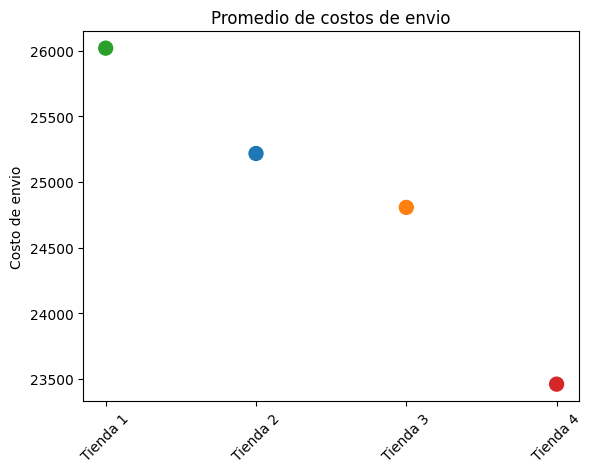

In [72]:
ig, ax3 = plt.subplots()

bar_colors = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']

ax3.scatter(promedio_envio['Tiendas'], promedio_envio['Promedio envio'], color=bar_colors, s=100, alpha=1)
ax3.set_ylabel('Costo de envio')
ax3.set_title('Promedio de costos de envio')
ax3.tick_params(axis='x', labelrotation=45)
plt.show()

##**Gráficos unidos**

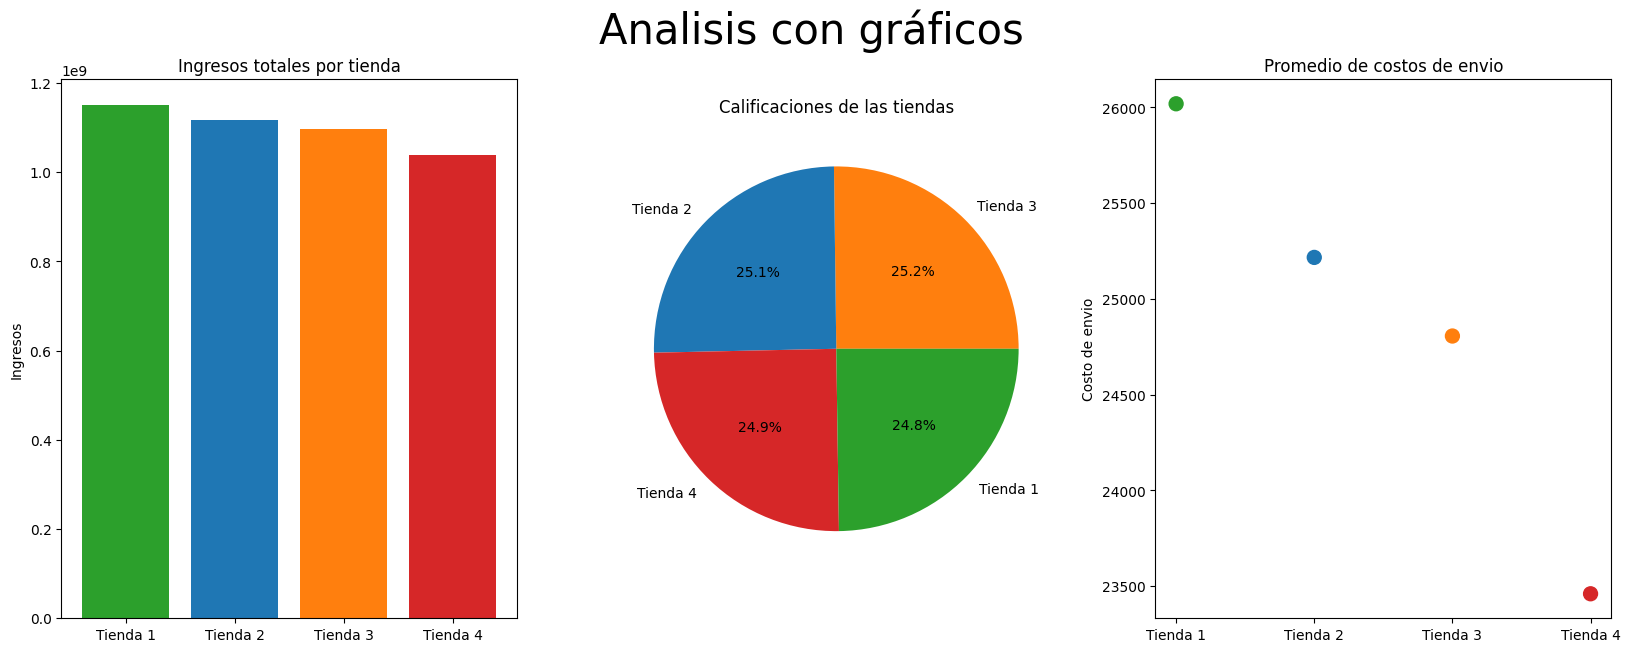

In [97]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

bar_colors = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']
bar_colors2 = ['tab:orange', 'tab:blue', 'tab:red', 'tab:green']

axs[0].bar(itdf['Tiendas'], itdf['Ingreso Total'], color=bar_colors)
axs[0].set_ylabel('Ingresos')
axs[0].set_title('Ingresos totales por tienda')
axs[0].tick_params(axis='x', labelrotation=0)


axs[1].pie(c_promedio['Calificacion Promedio'], colors=bar_colors2, labels=c_promedio['Tiendas'], autopct='%1.1f%%')
axs[1].set_title('Calificaciones de las tiendas')

axs[2].scatter(promedio_envio['Tiendas'], promedio_envio['Promedio envio'], color=bar_colors, s=100, alpha=1)
axs[2].set_ylabel('Costo de envio')
axs[2].set_title('Promedio de costos de envio')
axs[2].tick_params(axis='x', labelrotation=0)

fig.suptitle('Analisis con gráficos', fontsize=30)

plt.show()

#**Informe final**

La finalidad de este análisis es el de poder contribuir a la toma de desición respecto a la **venta** de una tienda dentro de un grupo de 4, para lo cual se realizo el estudio de los siguientes factores:
* Facturación
  * En este apartado se realizo el calculo de ventas totales por cada sucursal y se plasmo en un gráfico de barras, donde se puede obeservar que:
    * ***La tienda 1 es la que más factura***
    * ***La tienda 4 es la que menos factura***
* Ventas por categorías
  * Se realizo el conteo de productos totales vendidos dentro de cada categoria; si nos fijamos en el Top 3 de cada tienda encontramos las 3 mismas categorias:
    * ***Muebles***
    * ***Electrónicos***
    * ***Juguetes***
* Calificaciones promedio
  * En este apartado se calculó el promedio de calificaciones otorgadas por los usuarios respecto al servicio de las tiendas, dando como resultado lo siguiente:
    * ***La tienda 3 es la que posee la calificación promedio más alta***
    * ***La tienda 1 es la de la calficación más baja***
    * ⚠️***Sin embargo, hay que destacar que todas se mantienen muy cercanas a la misma calificación, la cual varia porcentualmente en 0.2%***⚠️
* Top ventas de productos
  * En este punto se buscaron cuales son los productos más vendidos por tienda y los menos vendidos, lo que puede destacar de este apartado es:
    * ***Tanto para los más vendidos como los menos vendidos no hay coincidencias entre productos entre las tiendas, por lo que podriamos aseverar que cada tienda tiene sus productos estrella.***
* Costos de envios
  * Se calculó el promedio de los costos de envio por tienda, surgiendo los siguientes resultados:
    * ***La tienda 1 es la que posee el envio más costoso***
    * ***La tienda 4 es la que posee el envio más barato***
    * ***⚠️Cabe destacar que la diferencia entre el envio más barato y el más costoso es del 10%, por lo que podria no implicar conste tan elevado al final.⚠️***

Tomando en cuenta el análisis completo y complementando visualmente con los gráficos que se consideraron relevantes para esta situación, se recomienda la venta de la **Tienda 4**, ya que esta como se aprecia en el apartado de "Gráficos unidos" en el gráfico de barras, es la sucursal que presenta **la menor facturación**; si bien se cuenta con las perspectivas de el gráfico "pie chart" donde la calificación realmente difiere muy poco entre sucursales si la **Tienda 4** deja de contribuir se observa que aun asi la calficación general respecto a la media de las 3 sucursales **(4.023)** restantes se mantiene por encima de la media cuando la **Tienda 4** contribuye **(4.017)**. Por último tenemos la perspectiva del gráfico "Scatter" donde se muestra los costos promedio de los envios, si bien la tienda objetivo representa los menores costos; al ser un gasto que es subsanado por lo clientes y contrastandolo con la tienda que mas vende y ser esta una variación del 10%, podemos decir que este factor no es suficiente para impugnar la venta de la **Tienda 4**.